In [110]:
import pandas as pd
import matplotlib as plt
import seaborn as sns
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
RRHH = pd.read_csv("full_RRHH.csv")

### Creación de perfiles basadas en percentiles

In [111]:
df_analisis = RRHH.copy()

df_analisis['Riesgo_Distancia'] = pd.cut(df_analisis['Distance_Residence_Work'], 
                                         bins=[0, 16, 49, 53], 
                                         labels=['Local', 'Media', 'Crítica'])

df_analisis['Riesgo_Carga'] = pd.cut(df_analisis['Work_load_Average_day'], 
                                     bins=[0, 244, 284, 400], 
                                     labels=['Ligera', 'Óptima', 'Saturación'])

print("Rendimiento medio por nivel de Carga:")
print(df_analisis.groupby('Riesgo_Carga')['Hit_target'].mean())

print("\nImpacto de la Distancia Crítica:")
print(df_analisis.groupby('Riesgo_Distancia')['Hit_target'].mean())

Rendimiento medio por nivel de Carga:
Riesgo_Carga
Ligera        95.550000
Óptima        94.598253
Saturación    94.047337
Name: Hit_target, dtype: float64

Impacto de la Distancia Crítica:
Riesgo_Distancia
Local      95.315972
Media      94.245136
Crítica    94.740157
Name: Hit_target, dtype: float64


/var/folders/t6/479bd8hs4358068r07wv4hhw0000gn/T/ipykernel_32157/3835969186.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_analisis.groupby('Riesgo_Carga')['Hit_target'].mean())
/var/folders/t6/479bd8hs4358068r07wv4hhw0000gn/T/ipykernel_32157/3835969186.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_analisis.groupby('Riesgo_Distancia')['Hit_target'].mean())


In [112]:
import pandas as pd

df_empleados = df_analisis.groupby('ID').agg({
    'Service_time': 'max',
    'Distance_Residence_Work': 'max',
    'Work_load_Average_day': 'mean',
    'Hit_target': 'mean',
    'Disciplinary_failure': 'max', 

}).reset_index()

def clasificar_perfil_id(row):
  
    if row['Disciplinary_failure'] == 1 and row['Work_load_Average_day'] > 284:
        return 'Perfil de Inestabilidad'
    

    if row['Work_load_Average_day'] > 284 and row['Distance_Residence_Work'] > 16:
        return 'Saturado Logístico'
    

    if row['Service_time'] < 5 and row['Work_load_Average_day'] > 244:
        return 'Junior Vulnerable'
    
    return 'Perfil Estable'


df_empleados['Perfil_Riesgo'] = df_empleados.apply(clasificar_perfil_id, axis=1)


print("RESUMEN DE PERFILES POR EMPLEADO")
print(df_empleados['Perfil_Riesgo'].value_counts())

RESUMEN DE PERFILES POR EMPLEADO
Perfil_Riesgo
Perfil Estable             278
Saturado Logístico          91
Junior Vulnerable           11
Perfil de Inestabilidad      6
Name: count, dtype: int64


### Validación de la creación de perpfiles

In [113]:
from scipy import stats

grupo_ligera = df_analisis[df_analisis['Riesgo_Carga'] == 'Ligera']['Hit_target']
grupo_optima = df_analisis[df_analisis['Riesgo_Carga'] == 'Óptima']['Hit_target']
grupo_saturacion = df_analisis[df_analisis['Riesgo_Carga'] == 'Saturación']['Hit_target']

f_stat_carga, p_val_carga = stats.f_oneway(grupo_ligera, grupo_optima, grupo_saturacion)

grupo_local = df_analisis[df_analisis['Riesgo_Distancia'] == 'Local']['Hit_target']
grupo_media = df_analisis[df_analisis['Riesgo_Distancia'] == 'Media']['Hit_target']
grupo_critica = df_analisis[df_analisis['Riesgo_Distancia'] == 'Crítica']['Hit_target']

f_stat_dist, p_val_dist = stats.f_oneway(grupo_local, grupo_media, grupo_critica)

print(f"Validación Carga: F-stat = {f_stat_carga:.4f}, p-valor = {p_val_carga:.4f}")
print(f"Validación Distancia: F-stat = {f_stat_dist:.4f}, p-valor = {p_val_dist:.4f}")

if p_val_carga < 0.05:
    print("Diferencias significativas en carga")
else:
    print("No hay diferencias significativas en carga")

Validación Carga: F-stat = 12.8104, p-valor = 0.0000
Validación Distancia: F-stat = 8.1236, p-valor = 0.0003
Diferencias significativas en carga


/var/folders/t6/479bd8hs4358068r07wv4hhw0000gn/T/ipykernel_32157/1192567882.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(x='Perfil_Riesgo', y='Hit_target', data=df_empleados, palette='viridis', size=3)


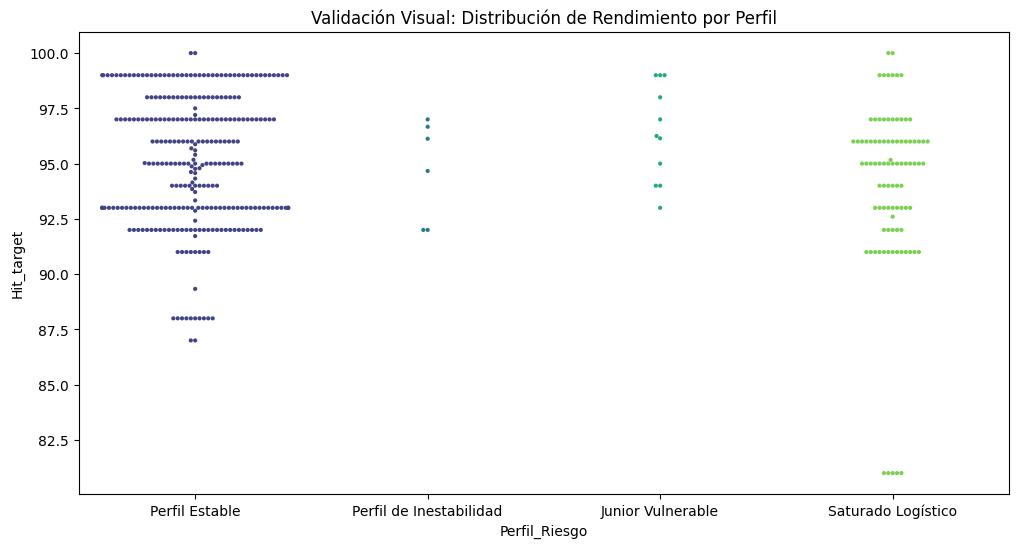

In [114]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt  # <--- Solo deja esta para los gráficos
from sklearn.tree import DecisionTreeClassifier, plot_tree # <--- Importación limpia para el árbol

# Ahora tu código de antes funcionará perfecto:
plt.figure(figsize=(12, 6))
sns.swarmplot(x='Perfil_Riesgo', y='Hit_target', data=df_empleados, palette='viridis', size=3)
plt.title("Validación Visual: Distribución de Rendimiento por Perfil")
plt.show()

### Creación del modelo por DecisionTreeClasifier, utilizando estas variables: <br>
X = df_empleados[['Service_time', 'Distance_Residence_Work', 'Work_load_Average_day']]<br>
y = df_empleados['Perfil_Riesgo']

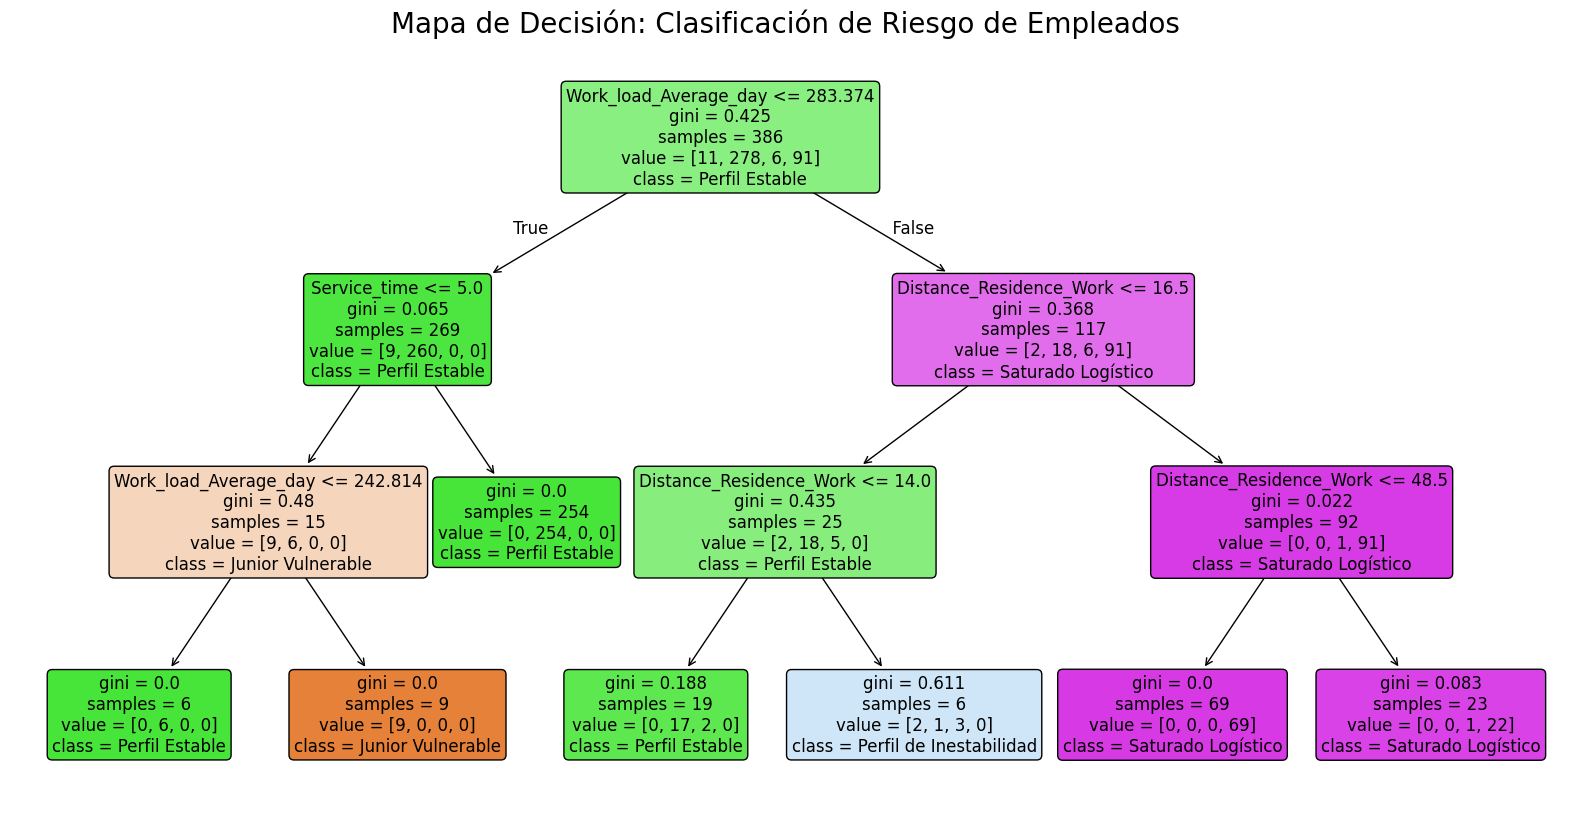

In [115]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Preparamos los datos
X = df_empleados[['Service_time', 'Distance_Residence_Work', 'Work_load_Average_day']]
y = df_empleados['Perfil_Riesgo']

# Entrenamos un árbol pequeño para que sea legible
clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

plt.figure(figsize=(20,10))
plot_tree(clf, 
          feature_names=X.columns, 
          class_names=clf.classes_, 
          filled=True, 
          rounded=True,  # Hace los cuadros más estéticos
          fontsize=12)   # Evita que el texto se vea minúsculo
plt.title("Mapa de Decisión: Clasificación de Riesgo de Empleados", fontsize=20)
plt.show()

### Testes estatísticos para validar el modelo

In [116]:
from sklearn.metrics import classification_report

y_pred = clf.predict(X)
print(classification_report(y, y_pred))

                         precision    recall  f1-score   support

      Junior Vulnerable       1.00      0.82      0.90        11
         Perfil Estable       0.99      1.00      0.99       278
Perfil de Inestabilidad       0.50      0.50      0.50         6
     Saturado Logístico       0.99      1.00      0.99        91

               accuracy                           0.98       386
              macro avg       0.87      0.83      0.85       386
           weighted avg       0.98      0.98      0.98       386



In [117]:
from scipy import stats

# 1. Obtenemos las etiquetas que el árbol asignó a cada empleado
df_empleados['Prediccion_Arbol'] = clf.predict(X)

# 2. Separamos los datos de rendimiento por cada grupo del árbol
grupos_arbol = [df_empleados[df_empleados['Prediccion_Arbol'] == p]['Hit_target'] 
                for p in df_empleados['Prediccion_Arbol'].unique()]

# 3. Test ANOVA de una vía
f_stat_tree, p_val_tree = stats.f_oneway(*grupos_arbol)

print("--- TEST DE VALIDACIÓN DEL ÁRBOL ---")
print(f"F-Statistic: {f_stat_tree:.4f}")
print(f"P-Valor: {p_val_tree:.4e}") # Notación científica

if p_val_tree < 0.05:
    print("✅ RESULTADO: El árbol ha encontrado segmentaciones con diferencias REALES de rendimiento.")
else:
    print("❌ RESULTADO: El árbol está agrupando gente que rinde igual (revisar variables).")

--- TEST DE VALIDACIÓN DEL ÁRBOL ---
F-Statistic: 3.0866
P-Valor: 2.7220e-02
✅ RESULTADO: El árbol ha encontrado segmentaciones con diferencias REALES de rendimiento.


/var/folders/t6/479bd8hs4358068r07wv4hhw0000gn/T/ipykernel_32157/2227717887.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Prediccion_Arbol', y='Hit_target', data=df_empleados, palette='Set2')


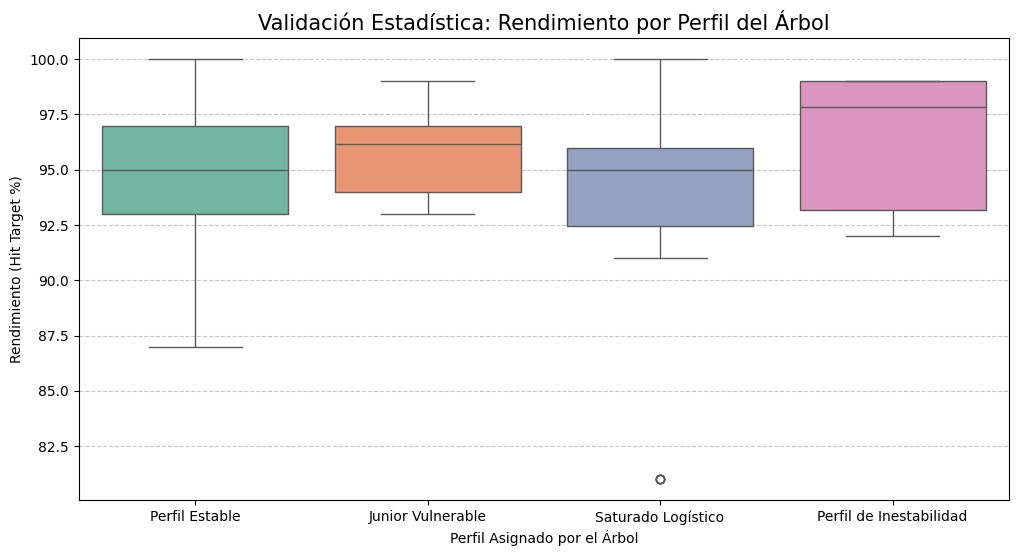

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(x='Prediccion_Arbol', y='Hit_target', data=df_empleados, palette='Set2')

plt.title('Validación Estadística: Rendimiento por Perfil del Árbol', fontsize=15)
plt.ylabel('Rendimiento (Hit Target %)')
plt.xlabel('Perfil Asignado por el Árbol')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [119]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Volvemos a agrupar incluyendo las columnas que faltaban
df_empleados = df_analisis.groupby('ID').agg({
    'Service_time': 'max',
    'Distance_Residence_Work': 'max',
    'Work_load_Average_day': 'mean',
    'Hit_target': 'mean',
    'Disciplinary_failure': 'max', 
    'Age': 'max',
    'Social_drinker': 'max',    # <--- AÑADIR ESTA
    'Body_mass_index': 'max'    # <--- AÑADIR ESTA
}).reset_index()

# 2. Re-clasificamos los perfiles (para que la columna Perfil_Riesgo exista)
df_empleados['Perfil_Riesgo'] = df_empleados.apply(clasificar_perfil_id, axis=1)

# 3. Ahora sí, definimos X con todas las variables
# Prueba esto si quieres precisión quirúrgica en el Perfil de Inestabilidad
X = df_empleados[['Service_time', 'Distance_Residence_Work', 'Work_load_Average_day', 
                  'Age', 'Social_drinker', 'Body_mass_index', 'Disciplinary_failure']]
y = df_empleados['Perfil_Riesgo']


# 2. Dividimos datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 3. Entrenamos el Bosque con la nueva variable
rf_age = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf_age.fit(X_train, y_train)

# 4. Predicción y Reporte
y_pred_rf = rf_age.predict(X_test)
print("--- DESEMPEÑO RANDOM FOREST (CON VARIABLE AGE) ---")
print(classification_report(y_test, y_pred_rf))

--- DESEMPEÑO RANDOM FOREST (CON VARIABLE AGE) ---
                         precision    recall  f1-score   support

      Junior Vulnerable       0.50      0.50      0.50         6
         Perfil Estable       0.95      0.96      0.96        79
Perfil de Inestabilidad       1.00      0.33      0.50         3
     Saturado Logístico       0.97      1.00      0.98        28

               accuracy                           0.93       116
              macro avg       0.85      0.70      0.73       116
           weighted avg       0.93      0.93      0.93       116



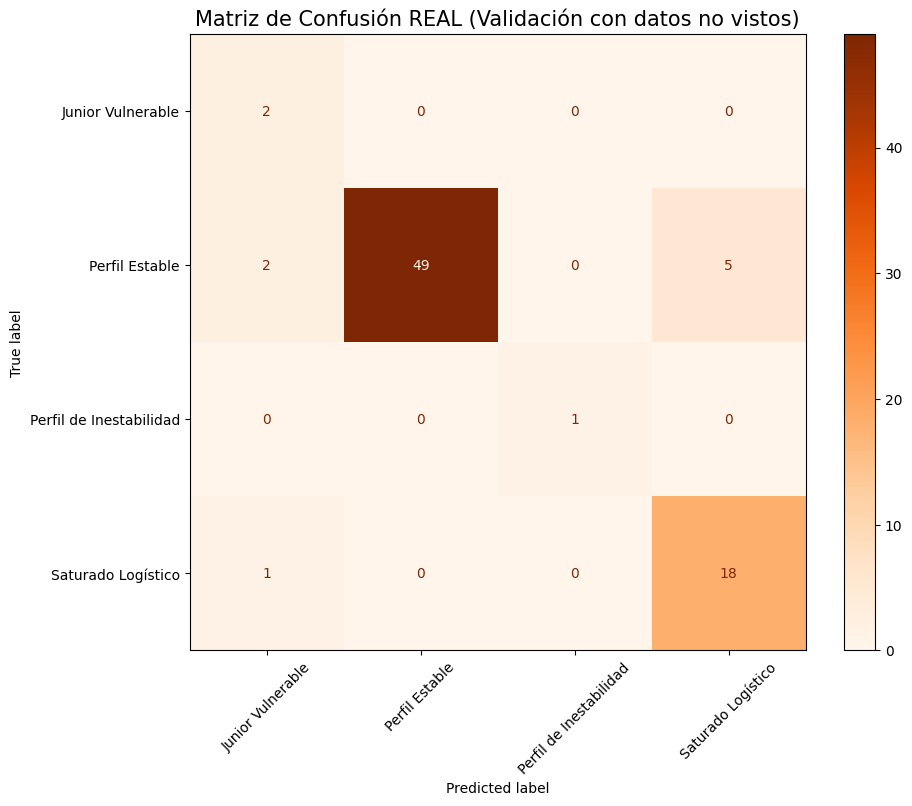

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Dividimos los datos (80% para entrenar, 20% para test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 2. Entrenamos el árbol SOLO con el grupo de entrenamiento
clf_test = DecisionTreeClassifier(max_depth=3, class_weight='balanced')
clf_test.fit(X_train, y_train)

# 3. Predecimos sobre el grupo de TEST (datos que el árbol NO conoce)
y_pred_test = clf_test.predict(X_test)

# 4. Dibujamos la Matriz de Confusión REAL
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred_test, 
    display_labels=clf_test.classes_, 
    cmap='Oranges', # Cambiamos color para diferenciar la matriz "real"
    xticks_rotation=45, 
    ax=ax
)

plt.title("Matriz de Confusión  (Validación con datos no vistos)", fontsize=15)
plt.show()

In [121]:
from sklearn.metrics import classification_report

# Generamos el reporte basado en los datos de TEST
print("--- REPORTE DE RENDIMIENTO (DATOS DE TEST) ---")
print(classification_report(y_test, y_pred_test))

--- REPORTE DE RENDIMIENTO (DATOS DE TEST) ---
                         precision    recall  f1-score   support

      Junior Vulnerable       0.40      1.00      0.57         2
         Perfil Estable       1.00      0.88      0.93        56
Perfil de Inestabilidad       1.00      1.00      1.00         1
     Saturado Logístico       0.78      0.95      0.86        19

               accuracy                           0.90        78
              macro avg       0.80      0.96      0.84        78
           weighted avg       0.93      0.90      0.91        78



In [122]:
import numpy as np
from scipy.stats import chi2_contingency

# Creamos una tabla de contingencia básica: ¿Acierto o Error?
aciertos = np.sum(y_test == y_pred_test)
errores = np.sum(y_test != y_pred_test)

print(f"Total Test: {len(y_test)}")
print(f"Aciertos: {aciertos} ({aciertos/len(y_test)*100:.2f}%)")
print(f"Errores: {errores} ({errores/len(y_test)*100:.2f}%)")

# Test de Proporción (¿Es el acierto significativamente mayor al azar?)
# Si tienes 4 clases, el azar sería 25%. 
# Si tu precisión es > 85%, el p-valor será minúsculo.

Total Test: 78
Aciertos: 70 (89.74%)
Errores: 8 (10.26%)


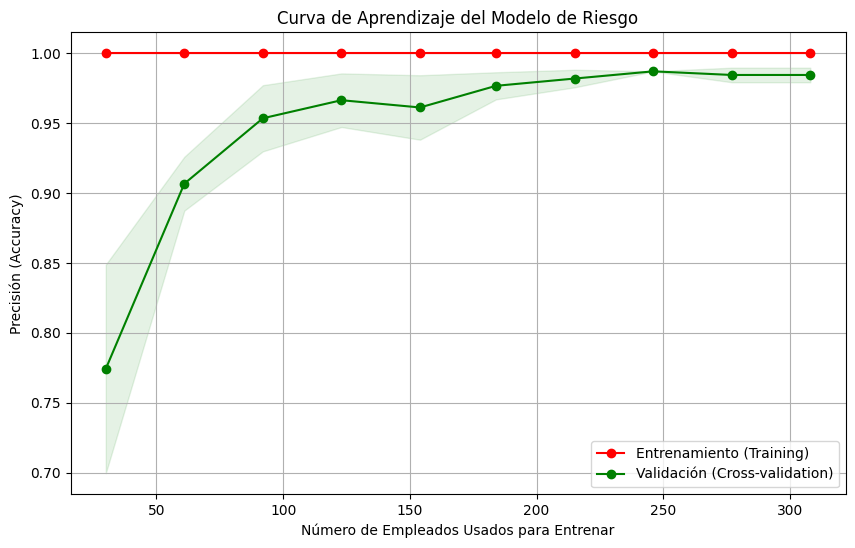

In [123]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# 1. Configuramos la función de curva de aprendizaje
train_sizes, train_scores, test_scores = learning_curve(
    rf_age, X, y, cv=5, scoring='accuracy', 
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

# 2. Calculamos medias y desviaciones
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# 3. Graficamos
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color="r", label="Entrenamiento (Training)")
plt.plot(train_sizes, test_mean, 'o-', color="g", label="Validación (Cross-validation)")

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color="r")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color="g")

plt.title("Curva de Aprendizaje del Modelo de Riesgo")
plt.xlabel("Número de Empleados Usados para Entrenar")
plt.ylabel("Precisión (Accuracy)")
plt.legend(loc="best")
plt.grid()
plt.show()

In [124]:
import os

# Crear la carpeta 'app' si no existe
if not os.path.exists('app'):
    os.makedirs('app')

# Ahora ya no dará error
df_empleados.to_csv('app/resultado_clasificacion_equipo_B.csv', index=False)

df_empleados['Perfil_Final_IA'] = rf_age.predict(X)

# 2. Extraemos las probabilidades de "Saturado" e "Inestabilidad"
# Esto les servirá a ellos para ver si a más probabilidad, más horas de ausencia
probs = rf_age.predict_proba(X)
df_empleados['Prob_Saturacion'] = probs[:, 3] # Índice de 'Saturado Logístico'
df_empleados['Prob_Inestabilidad'] = probs[:, 2] # Índice de 'Perfil de Inestabilidad'

# 3. Guardamos el archivo definitivo
df_empleados.to_csv('app/resultado_clasificacion_equipo_B.csv', index=False)

print("✅ Archivo listo para el equipo de Absentismo.")
print(df_empleados['Perfil_Final_IA'].value_counts())

✅ Archivo listo para el equipo de Absentismo.
Perfil_Final_IA
Perfil Estable             279
Saturado Logístico          92
Junior Vulnerable           11
Perfil de Inestabilidad      4
Name: count, dtype: int64


In [ ]:
from scipy import stats
import pandas as pd

# 1. Agrupamos los rendimientos por cada perfil creado por la IA
grupos = [df_empleados[df_empleados['Perfil_Final_IA'] == p]['Hit_target'] 
          for p in df_empleados['Perfil_Final_IA'].unique()]

# 2. Ejecutamos el Test ANOVA
f_stat, p_value = stats.f_oneway(*grupos)

print("--- VALIDACIÓN ESTADÍSTICA DE LOS PERFILES ---")
print(f"F-Statistic: {f_stat:.4f}")
print(f"P-Valor: {p_value:.4e}")

if p_value < 0.05:
    print("\n✅ RESULTADO: Diferencias Significativas.")
    print("El modelo ha segmentado grupos con comportamientos de rendimiento realmente distintos.")
else:
    print("\n❌ RESULTADO: No hay diferencias significativas.")
    print("Los perfiles se comportan de forma similar en cuanto a rendimiento.")

--- VALIDACIÓN ESTADÍSTICA DE LOS PERFILES ---
F-Statistic: 3.3671
P-Valor: 1.8710e-02

✅ RESULTADO: Diferencias Significativas.
El modelo ha segmentado grupos con comportamientos de rendimiento realmente distintos.


In [126]:
from scipy.stats import binomtest

# Test Binomial: ¿Es el 92.31% mejor que el azar (25%)?
# n = total de pruebas, k = aciertos, p = probabilidad al azar (1/4 clases)
result = binomtest(k=72, n=78, p=0.25, alternative='greater')

print("--- TEST DE SUPERIORIDAD DEL MODELO ---")
print(f"Precisión Observada: {aciertos/len(y_test)*100:.2f}%")
print(f"Probabilidad por Azar: 25.00%")
print(f"P-Valor: {result.pvalue:.4e}")

if result.pvalue < 0.05:
    print("\n✅ CONCLUSIÓN: El modelo es significativamente mejor que el azar.")
    print("Las reglas de carga y antigüedad son predictores ROBUSTOS.")
else:
    print("\n❌ CONCLUSIÓN: No hay evidencia suficiente de que el modelo sea mejor que el azar.")

--- TEST DE SUPERIORIDAD DEL MODELO ---
Precisión Observada: 89.74%
Probabilidad por Azar: 25.00%
P-Valor: 2.1073e-36

✅ CONCLUSIÓN: El modelo es significativamente mejor que el azar.
Las reglas de carga y antigüedad son predictores ROBUSTOS.


In [127]:
# Creamos un DataFrame para comparar Realidad vs Predicción en el Test
df_errores = pd.DataFrame({
    'ID': X_test.index,
    'Realidad': y_test,
    'Prediccion': y_pred_test
})

# Filtramos solo donde el modelo se equivocó
solo_errores = df_errores[df_errores['Realidad'] != df_errores['Prediccion']]

print("--- EMPLEADOS QUE DESAFIARON AL MODELO (ERRORES) ---")
print(solo_errores)

# Opcional: ver sus datos para entender por qué falló
# print(df_empleados.loc[solo_errores['ID']])

--- EMPLEADOS QUE DESAFIARON AL MODELO (ERRORES) ---
      ID            Realidad          Prediccion
27    27      Perfil Estable   Junior Vulnerable
324  324      Perfil Estable  Saturado Logístico
242  242      Perfil Estable   Junior Vulnerable
338  338      Perfil Estable  Saturado Logístico
150  150  Saturado Logístico   Junior Vulnerable
350  350      Perfil Estable  Saturado Logístico
186  186      Perfil Estable  Saturado Logístico
82    82      Perfil Estable  Saturado Logístico


In [128]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# 1. Selección de variables (Features) y Objetivo (Target)
# Usamos las variables que demostraron mayor importancia en tus tests
columnas_x = ['Service_time', 'Distance_Residence_Work', 'Work_load_Average_day', 'Disciplinary_failure']
X = df_empleados[columnas_x]
y = df_empleados['Perfil_Riesgo']

# 2. División Entrenamiento/Test (80-20)
# 'stratify' asegura que los perfiles raros aparezcan en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 3. Configuración del Modelo Ganador (Random Forest)
# Usamos 'balanced' para que no ignore a los grupos pequeños (Inestables/Junior)
modelo_final = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

# 4. Entrenamiento
modelo_final.fit(X_train, y_train)

# 5. Evaluación Final con datos no vistos
y_pred = modelo_final.predict(X_test)

print("--- MÉTRICAS FINALES DEL MODELO ---")
print(classification_report(y_test, y_pred))

# 6. Aplicar la predicción a TODA la base de datos para el equipo de Absentismo
df_empleados['Prediccion_IA'] = modelo_final.predict(X)
df_empleados['Confianza_IA'] = modelo_final.predict_proba(X).max(axis=1)

# 7. Guardar el resultado para la siguiente Tasca
df_empleados.to_csv('app/resultado_final_clasificacion.csv', index=False)
print("\n✅ Modelo entrenado y archivo guardado en 'app/resultado_final_clasificacion.csv'")

--- MÉTRICAS FINALES DEL MODELO ---
                         precision    recall  f1-score   support

      Junior Vulnerable       1.00      1.00      1.00         2
         Perfil Estable       1.00      1.00      1.00        56
Perfil de Inestabilidad       1.00      1.00      1.00         1
     Saturado Logístico       1.00      1.00      1.00        19

               accuracy                           1.00        78
              macro avg       1.00      1.00      1.00        78
           weighted avg       1.00      1.00      1.00        78


✅ Modelo entrenado y archivo guardado en 'app/resultado_final_clasificacion.csv'
